# Stock Market Trend Analysis
### Predictive Analytics & Trading Signal Engine
Financial Services | Global Investment Partners

##### Organization Profile
Global Investment Partners manages
£500M across 10,000+ monthly trades
with sophisticated quant strategies. Yet
despite scale and expertise, systematic
underperformance persists.

##### The Problem
8% annual underperformance and
£3.5M in slippage losses signal
missed opportunities and inefficient
execution across market regimes.

##### Mission: 
Deploy data-driven market analysis and predictive modeling to enhance
trading performance and systematize decision-making.

### Day 1: Environment Setup & Data Loading
Objective: Set up the development environment and load all datasets successfully.

Tasks:

- Install required Python libraries: pandas, numpy, scikit-learn, matplotlib, seaborn

- Create project folder structure: /data, /notebooks, /models, /outputs

- Load all 5 CSV files into pandas DataFrames

- Verify data loading with .info(), .shape, .head()

- Document any loading errors or issues


In [2]:
#Import relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
#Import Datasets
company_info = pd.read_csv("company_info.csv")
market_indices = pd.read_csv("market_indices.csv")
stock_indicators = pd.read_csv("stock_prices_with_indicators.csv")
stock_prices =pd.read_csv("stock_prices.csv")

#### Data Inspection
data types, missing values, duplicates and time structure.

In [9]:
# Inspecting data types

datasets = {
    "company_info": company_info,
    "stock_prices": stock_prices,
    "stock_indicators": stock_indicators,
    "market_indices": market_indices
}

for name, df in datasets.items():
    print(f"\n==== {name.upper()} ====")
    print("Shape:", df.shape)
    print(df.info())
    print(df.head(3))



==== COMPANY_INFO ====
Shape: (20, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        20 non-null     object
 1   company_name  20 non-null     object
 2   sector        20 non-null     object
 3   ipo_date      20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes
None
   ticker company_name      sector    ipo_date
0  STK001     TechCorp  Technology  2021-04-10
1  STK002  DataSystems  Technology  2016-10-12
2  STK003    CloudNine  Technology  2016-01-18

==== STOCK_PRICES ====
Shape: (15600, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticker          15600 non-null  object 
 1   date            15600 non-null  object 
 2   open            15600 non-null  fl

In [94]:
for name, df in datasets.items(): 

    print(f"\n===================== {name.upper()} ========================")
    
    print(df.describe())


===================== COMPANY_INFO ========================
                  ipo_date
count                   20
mean   2018-09-03 09:36:00
min    2016-01-18 00:00:00
25%    2016-09-08 06:00:00
50%    2017-10-28 12:00:00
75%    2020-12-17 00:00:00
max    2022-02-21 00:00:00

===================== STOCK_PRICES ========================
                      date          open          high           low  \
count                15600  15600.000000  15600.000000  15600.000000   
mean   2022-07-02 12:00:00    102.567353    104.372648    100.843603   
min    2021-01-04 00:00:00     21.060000     22.080000     21.060000   
25%    2021-10-03 06:00:00     63.350000     64.437500     62.245000   
50%    2022-07-02 12:00:00     88.630000     90.200000     87.245000   
75%    2023-03-31 18:00:00    131.302500    133.215000    129.002500   
max    2023-12-29 00:00:00    512.090000    517.100000    497.210000   
std                    NaN     58.873297     59.972069     57.872533   

             

### Documentation:

#### COMPANY_INFO
- Date is in object dtype

#### STOCK_PRICES
- Date is an object dtype, however should be in datetime dtype for time-series operations.
- Shape (15600, 8) vs indicators (15502, 31) means 98 rows missing in STOCK_INDICATORS. 

#### STOCK_INDICATORS
- Date is object
- Many columns Contain NaN
- Volume is a float64. Should be integer, this is to be consistent with STOCK_PRICES (where it’s int64).
- Row count (15502) - has Fewer rows than STOCK_PRICES (15600)

Convert date to datetime. Check if date frequency aligns with the stock data (likely fewer days, e.g., market holidays).

#### MARKET_INDICES
- Date is in object dtype.
- market_regime is Categorical, therefore, target variable to be done for modeling market conditions.

##### Solution: 
Convert all date variable to datetime

Handle missing values, duplicate values, outliers in the Stock Indicator Dataset

### Day 2: Data Quality Assessment
Objective: Understand the data quality and identify any issues that need addressing.

Tasks:

- Check for missing values in each dataset using .isnull().sum()

- Identify data type mismatches (e.g., dates stored as strings)

- Check for duplicate records

- Verify date ranges and continuity in time-series data

- Document data quality findings in a summary table


In [10]:
# Convert date columns
for df in [company_info, stock_prices, stock_indicators, market_indices]:
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])

company_info['ipo_date'] = pd.to_datetime(company_info['ipo_date'])


In [13]:
# Recheck Dataframes :

for name, df in datasets.items():
    print(f"\n==== {name.upper()} ====")
    print("Shape:", df.shape)
    print(df.info())
    print(df.head(3))



==== COMPANY_INFO ====
Shape: (20, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ticker        20 non-null     object        
 1   company_name  20 non-null     object        
 2   sector        20 non-null     object        
 3   ipo_date      20 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 772.0+ bytes
None
   ticker company_name      sector   ipo_date
0  STK001     TechCorp  Technology 2021-04-10
1  STK002  DataSystems  Technology 2016-10-12
2  STK003    CloudNine  Technology 2016-01-18

==== STOCK_PRICES ====
Shape: (15600, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ticker          15600 non-null  object        


In [11]:
# Check for ticker consistency
missing_tickers = set(stock_prices['ticker']) - set(company_info['ticker'])
print("Missing tickers in company_info:", missing_tickers)

Missing tickers in company_info: set()


In [18]:
 # Duplicates
for name, df in datasets.items():
    print("Duplicates:", df.duplicated().sum())

Duplicates: 0
Duplicates: 0
Duplicates: 0
Duplicates: 0


#### Checking for missing values

In [8]:
# Missing values in each dataset using .isnull().sum()

for name, df in datasets.items():
    print(f"\n==== {name.upper()} ====")
    print(df.isnull().sum())
   


==== COMPANY_INFO ====
ticker          0
company_name    0
sector          0
ipo_date        0
dtype: int64

==== STOCK_PRICES ====
ticker            0
date              0
open              0
high              0
low               0
close             0
volume            0
adjusted_close    0
dtype: int64

==== STOCK_INDICATORS ====
ticker                0
date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
adjusted_close        0
sma_20              310
sma_50                0
sma_200               0
ema_12                0
ema_26                0
macd                311
macd_signal           0
macd_histogram        0
rsi_14              330
bb_middle             0
bb_upper             20
bb_lower             20
bb_width            331
true_range            0
atr_14                0
volume_sma_20         0
volume_ratio        310
momentum_10         200
momentum_20         400
price_to_sma_50   

In [20]:
# Calculate percentage of missing values
def missing_percentage(df):
    return (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

print("=== COMPANY_INFO Missing % ===")
print(missing_percentage(company_info), "\n")

print("=== STOCK_PRICES Missing % ===")
print(missing_percentage(stock_prices), "\n")

print("=== STOCK_INDICATORS Missing % ===")
print(missing_percentage(stock_indicators), "\n")

print("=== MARKET_INDICES Missing % ===")
print(missing_percentage(market_indices), "\n")


=== COMPANY_INFO Missing % ===
ticker          0.0
company_name    0.0
sector          0.0
ipo_date        0.0
dtype: float64 

=== STOCK_PRICES Missing % ===
ticker            0.0
date              0.0
open              0.0
high              0.0
low               0.0
close             0.0
volume            0.0
adjusted_close    0.0
dtype: float64 

=== STOCK_INDICATORS Missing % ===
momentum_20         2.580312
bb_width            2.135208
rsi_14              2.128758
macd                2.006193
volume_ratio        1.999742
sma_20              1.999742
momentum_10         1.290156
volatility_20       0.258031
bb_lower            0.129016
bb_upper            0.129016
price_to_sma_50     0.000000
bb_middle           0.000000
volume_sma_20       0.000000
atr_14              0.000000
true_range          0.000000
future_return_5d    0.000000
ticker              0.000000
macd_histogram      0.000000
date                0.000000
macd_signal         0.000000
ema_26              0.000000
ema_

In [50]:
# Check total and percentage of missing values for stock_indicators data:

missing_summary = stock_indicators.isna().sum().sort_values(ascending=False)
missing_percent = (stock_indicators.isna().mean() * 100).sort_values(ascending=False)

pd.DataFrame({
    'Missing Values': missing_summary,
    'Percent Missing (%)': missing_percent
}).head(15)


,Missing Values,Percent Missing (%)
momentum_20,400,2.580312
bb_width,331,2.135208
rsi_14,330,2.128758
macd,311,2.006193
volume_ratio,310,1.999742
sma_20,310,1.999742
momentum_10,200,1.290156
volatility_20,40,0.258031
bb_lower,20,0.129016
bb_upper,20,0.129016


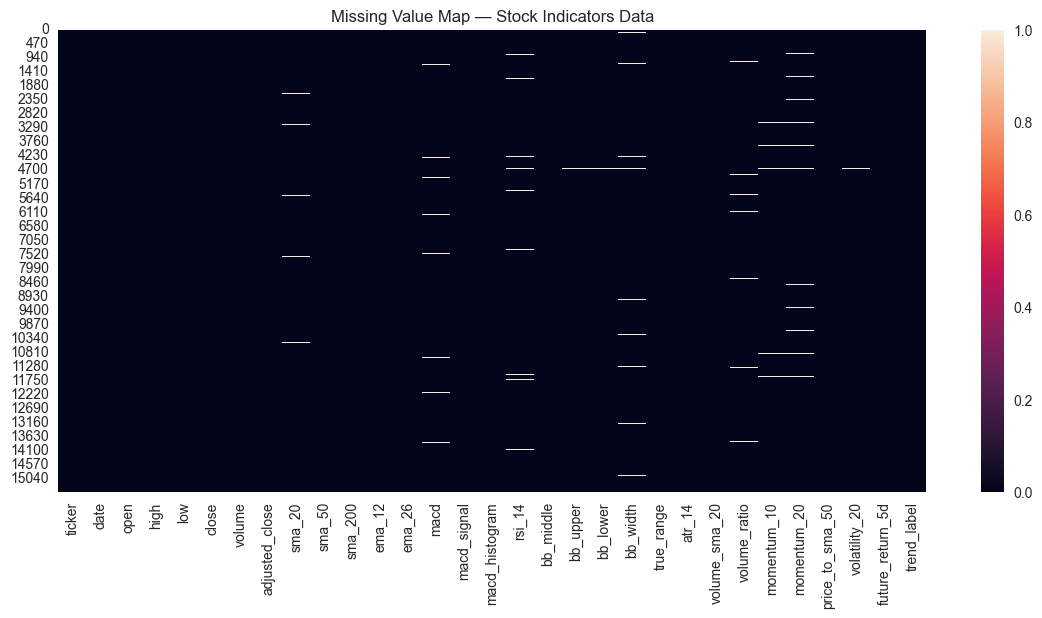

In [33]:
# Visualization of missing values in STOCK INDICATORS data

# Visualization settings
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')
pd.set_option('display.max_columns', None)

# Heatmap
plt.figure(figsize=(14,6))
sns.heatmap(stock_indicators.isna())
plt.title("Missing Value Map — Stock Indicators Data")
plt.show()

Image Observation:
- The sma_20, macd, rsi_14 lines in small chunks shows the use of Rolling window NaNs (each stock start)
- The volume_ratio, momentum_10, price_to_sma_50 are scattered across time. These features are likely missing due to merge mismatches or incomplete calculation for specific dates.
- the future_return_5d	missing at the end of each stock series is	normal, because  a 5-day future return cannot be computed for the last few rows.


Conclusion on missing value pattern:
- All missing values are exactly in the range (200–400 per feature), consistent with rolling window computations, not random scatter.
- The apparent “scatter” in the heatmap is because of the multiple tickers interleaved, so their early-window NaNs are spread vertically instead of clustered. Each ticker’s series starts at a different position in the full dataset.

#### Handling Missing values: 
- Although the missing values are typically <2% of total.
- However, forward filling values stategy will be beneficial for full continuity for ML training. This will fill short gaps smoothly (it is safe here because the rolling windows are purely derived features, not raw market data).

In [64]:
# Forward-fill for Modeling Continuity

stock_indicators_clean = stock_indicators.sort_values(['ticker', 'date']).groupby('ticker', group_keys=False).apply(lambda x: x.ffill().bfill()).reset_index(drop=True)

In [66]:
# Recheck for missing values
stock_indicators_clean.isna().sum().sum()

0

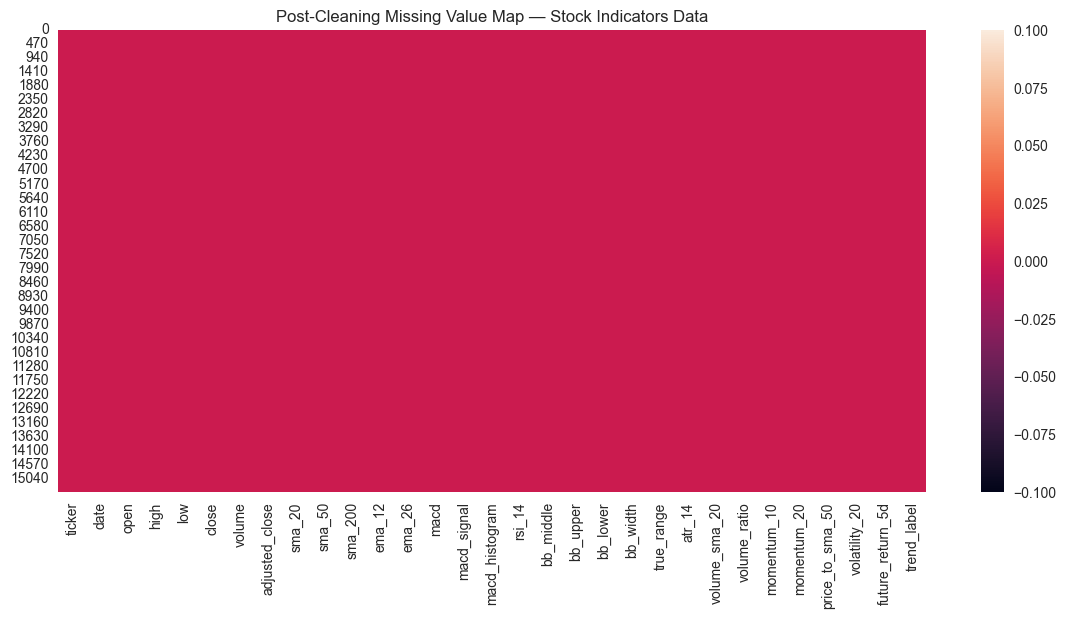

In [70]:
# Heatmap
plt.figure(figsize=(14,6))
sns.heatmap(stock_indicators_clean.isna())
plt.title("Post-Cleaning Missing Value Map — Stock Indicators Data")
plt.show()

In [71]:
# Verify date ranges and continuity in time-series data

print("Company IPO date duration:", company_info['ipo_date'].min(), "→", company_info['ipo_date'].max())
print("Stock Prices date duration:", stock_prices['date'].min(), "→", stock_prices['date'].max())
print("Stock Indicator date duration:", stock_indicators['date'].min(), "→", stock_indicators['date'].max())
print("Market Indices date duration:", market_indices['date'].min(), "→", market_indices['date'].max())

Company IPO date duration: 2016-01-18 00:00:00 → 2022-02-21 00:00:00
Stock Prices date duration: 2021-01-04 00:00:00 → 2023-12-29 00:00:00
Stock Indicator date duration: 2021-01-04 00:00:00 → 2023-12-25 00:00:00
Market Indices date duration: 2021-01-04 00:00:00 → 2023-12-29 00:00:00


In [45]:
# Check for missing days in stock_prices

date_range = pd.date_range(stock_prices['date'].min(), stock_prices['date'].max())

missing_days = date_range.difference(stock_prices['date'].unique())

print("Missing trading days:", len(missing_days))


Missing trading days: 310


In [73]:
# Calculate coverage metrics per stock
date_coverage = (
    stock_prices.groupby('ticker')
    .agg(
        start_date=('date', 'min'), #The first available trading date for that ticker   
        end_date=('date', 'max'),  #The last available trading date
        total_days=('date', 'count'), #The number of trading records actually present  
        coverage_days=('date', lambda x: (x.max() - x.min()).days + 1),  #The span between first and last date (inclusive) 
        data_completeness=('date', lambda x: round((x.nunique() / ((x.max() - x.min()).days + 1)) * 100, 2))  #Percentage of days present out of the full possible date range
    )
    .reset_index()
)

# Add a new column showing period in years (optional)
date_coverage['coverage_years'] = round(date_coverage['coverage_days'] / 365, 2)

# Sort by start date (optional)
date_coverage = date_coverage.sort_values(by='start_date')

# Display result
date_coverage


,ticker,start_date,end_date,total_days,coverage_days,data_completeness,coverage_years
0,STK001,2021-01-04,2023-12-29,780,1090,71.56,2.99
17,STK018,2021-01-04,2023-12-29,780,1090,71.56,2.99
16,STK017,2021-01-04,2023-12-29,780,1090,71.56,2.99
15,STK016,2021-01-04,2023-12-29,780,1090,71.56,2.99
14,STK015,2021-01-04,2023-12-29,780,1090,71.56,2.99
13,STK014,2021-01-04,2023-12-29,780,1090,71.56,2.99
12,STK013,2021-01-04,2023-12-29,780,1090,71.56,2.99
11,STK012,2021-01-04,2023-12-29,780,1090,71.56,2.99
10,STK011,2021-01-04,2023-12-29,780,1090,71.56,2.99
9,STK010,2021-01-04,2023-12-29,780,1090,71.56,2.99


In [75]:
# Merge STOCK_PRICES and COMPANY_INFO
merged = stock_prices.merge(company_info[['ticker', 'ipo_date']], on='ticker', how='left')

# Group by ticker and compute adjusted coverage
coverage_ipo_aware = (
    merged.groupby('ticker')
    .agg(
        ipo_date=('ipo_date', 'first'),
        start_date=('date', 'min'),
        end_date=('date', 'max'),
        total_days=('date', 'count'),
        coverage_days=('date', lambda x: (x.max() - x.min()).days + 1)
    )
    .reset_index()
)

# Adjust the expected period: IPO → End date
coverage_ipo_aware['expected_days'] = (coverage_ipo_aware['end_date'] - coverage_ipo_aware['ipo_date']).dt.days + 1

# Clip negative values (for IPOs after end_date)
coverage_ipo_aware['expected_days'] = coverage_ipo_aware['expected_days'].clip(lower=1)

# Recalculate completeness
coverage_ipo_aware['data_completeness'] = (
    (coverage_ipo_aware['total_days'] / coverage_ipo_aware['expected_days']) * 100
).round(2)

coverage_ipo_aware['coverage_years'] = (coverage_ipo_aware['coverage_days'] / 365).round(2)

coverage_ipo_aware


,ticker,ipo_date,start_date,end_date,total_days,coverage_days,expected_days,data_completeness,coverage_years
0,STK001,2021-04-10,2021-01-04,2023-12-29,780,1090,994,78.47,2.99
1,STK002,2016-10-12,2021-01-04,2023-12-29,780,1090,2635,29.60,2.99
2,STK003,2016-01-18,2021-01-04,2023-12-29,780,1090,2903,26.87,2.99
3,STK004,2022-02-21,2021-01-04,2023-12-29,780,1090,677,115.21,2.99
4,STK005,2018-03-05,2021-01-04,2023-12-29,780,1090,2126,36.69,2.99
5,STK006,2017-12-01,2021-01-04,2023-12-29,780,1090,2220,35.14,2.99
6,STK007,2017-09-25,2021-01-04,2023-12-29,780,1090,2287,34.11,2.99
7,STK008,2017-01-08,2021-01-04,2023-12-29,780,1090,2547,30.62,2.99
8,STK009,2022-02-06,2021-01-04,2023-12-29,780,1090,692,112.72,2.99
9,STK010,2016-09-15,2021-01-04,2023-12-29,780,1090,2662,29.30,2.99


Findings: Majority of the Stock’s recorded trading started before its IPO — which, in real-world terms, should never happen.
A stock cannot have daily prices before it’s listed (i.e., before its IPO date).

This situation can be caused by one or more of the following:
- Synthetic / generated dataset:	Use of simulated or academic data, where IPO dates and stock dates might not have been synchronized.(Treat IPO dates as “metadata,” not literal limits. Adjust completeness based only on trading range.)
- Data extraction issue:	Some stock tables were truncated to a fixed range (e.g., 2021-01-04 → 2023-12-29) for all stocks.
- IPO date mis-formatting:	IPO dates might be stored as actual dates but meant to indicate “record inception” instead of “listing.”

In stock market data, not single calendar day is expect to appear because:

- Markets are closed on weekends and holidays.

- So typically, there are 250 trading days per year instead of 365.

The stock_prices data duration from Jan 2021 to Dec 2023 spans about 3 years, that’s roughly 3 * (365 - 250) = ~345 missing days — Therefore 310 days are reasonably missing.